# Unit 9 code companion: Causal Thinking

Build each of the three third-variable roles in a world where you set the truth, then watch the same patterns appear in real data. If you can produce a bias on purpose, you can recognize it in the wild.

Run the cells in order. Each section matches a moment in the slides. The point is to see the mechanism move when you change the inputs, so change them.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

rng = np.random.default_rng(220)
plt.rcParams["figure.figsize"] = (7, 3.5)

## 1. A collider: making a correlation out of nothing

Two independent variables. Select on their sum, and they become related.

In [2]:
d1 = rng.integers(1, 7, 4000)
d2 = rng.integers(1, 7, 4000)
keep = (d1 + d2) >= 9

print(f"correlation among ALL rolls           : {np.corrcoef(d1, d2)[0,1]:+.3f}")
print(f"correlation among rolls summing to 9+ : {np.corrcoef(d1[keep], d2[keep])[0,1]:+.3f}")
print(f"\n{keep.sum()} of {len(d1)} rolls survived the filter")

correlation among ALL rolls           : -0.004
correlation among rolls summing to 9+ : -0.511

1122 of 4000 rolls survived the filter


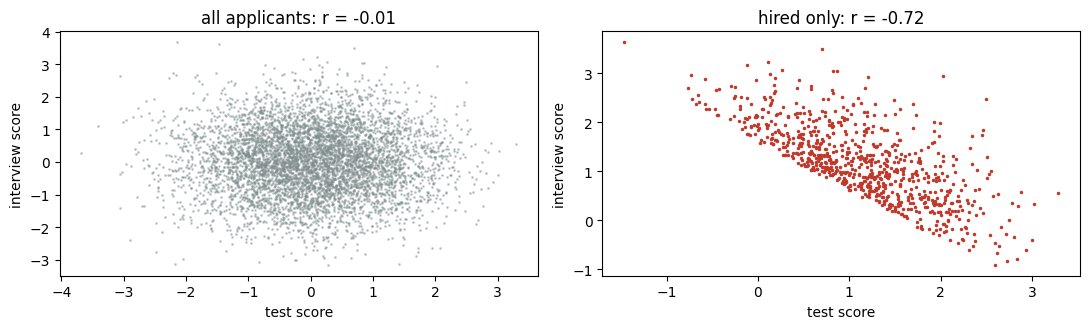

In [3]:
# The same structure with continuous variables: hiring on test + interview.
test = rng.normal(size=6000)
interview = rng.normal(size=6000)
hired = (test + interview) > 1.6

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].plot(test, interview, ".", ms=2, color="#7f8c8d", alpha=.4)
axes[0].set_title(f"all applicants: r = {np.corrcoef(test, interview)[0,1]:+.2f}")
axes[1].plot(test[hired], interview[hired], ".", ms=3, color="#c0392b")
axes[1].set_title(f"hired only: r = {np.corrcoef(test[hired], interview[hired])[0,1]:+.2f}")
for ax in axes: ax.set_xlabel("test score"); ax.set_ylabel("interview score")
plt.tight_layout(); plt.show()

An HR analyst studying current employees would conclude that test performance and interview performance trade off against each other. They do not. The hiring rule created the pattern, and it exists only inside the hired group.

## 2. A confounder: an effect that is not there



In [4]:
n = 4000
z = rng.normal(0, 1, n)                       # lurking variable
x = 0.8*z + rng.normal(0, 0.6, n)             # treatment, driven by z
y = 2.0*z + rng.normal(0, 1.0, n)             # outcome, driven by z, NOT by x

naive = sm.OLS(y, sm.add_constant(x)).fit()
adj = sm.OLS(y, sm.add_constant(np.column_stack([x, z]))).fit()
print(f"TRUE effect of x on y      : 0.000")
print(f"naive estimate             : {naive.params[1]:+.3f}  (t = {naive.tvalues[1]:6.1f})")
print(f"controlling for z          : {adj.params[1]:+.3f}  (t = {adj.tvalues[1]:6.1f})")

TRUE effect of x on y      : 0.000
naive estimate             : +1.586  (t =   63.2)
controlling for z          : -0.003  (t =   -0.1)


## 3. A mediator: controlling away a real effect



In [5]:
n = 4000
train = rng.integers(0, 2, n)                 # randomized training
skill = 1.5*train + rng.normal(0, 1, n)       # training raises skill
sales = 2.0*skill + rng.normal(0, 1, n)       # skill raises sales; no other path

total = sm.OLS(sales, sm.add_constant(train)).fit()
direct = sm.OLS(sales, sm.add_constant(np.column_stack([train, skill]))).fit()
print(f"TRUE total effect of training : {1.5*2.0:.2f}")
print(f"estimated total effect        : {total.params[1]:.3f}   <-- correct")
print(f"'controlling for skill'       : {direct.params[1]:.3f}   <-- the effect vanishes")

TRUE total effect of training : 3.00
estimated total effect        : 3.031   <-- correct
'controlling for skill'       : -0.012   <-- the effect vanishes


Training was randomized, so the total effect is unbiased. Controlling for skill blocks the only channel through which training works and reports approximately zero. Adding a variable is not a safe default: it is a claim about the causal structure.

## 4. The same story in real data



In [6]:
cars = pd.read_csv("https://richardson.byu.edu/220/cars.csv").dropna()
raw = sm.OLS(cars.mpg, sm.add_constant(cars[["acceleration"]])).fit()
adj = sm.OLS(cars.mpg, sm.add_constant(cars[["acceleration", "weight"]])).fit()
print(f"raw slope on acceleration       : {raw.params['acceleration']:+.3f} mpg per second")
print(f"adjusting for weight            : {adj.params['acceleration']:+.3f} mpg per second")
print(f"share of the raw association that survived: "
      f"{adj.params['acceleration']/raw.params['acceleration']:.0%}")

raw slope on acceleration       : +1.198 mpg per second
adjusting for weight            : +0.262 mpg per second
share of the raw association that survived: 22%


## 5. Difference in differences, and what breaks it



In [7]:
def did(treat_effect, common_trend, pre_gap=12.0, n=400, treated_drift=0.0):
    """treated_drift lets us violate parallel trends on purpose."""
    ctrl_pre  = rng.normal(30, 5, n)
    ctrl_post = ctrl_pre + common_trend + rng.normal(0, 3, n)
    trt_pre   = rng.normal(30 + pre_gap, 5, n)
    trt_post  = trt_pre + common_trend + treated_drift + treat_effect + rng.normal(0, 3, n)
    return ((trt_post.mean() - trt_pre.mean()) - (ctrl_post.mean() - ctrl_pre.mean()))

print(f"true effect 7, parallel trends hold      : DiD = {did(7, 6):.2f}")
print(f"true effect 0, parallel trends hold      : DiD = {did(0, 6):.2f}")
print(f"true effect 0, treated region drifting +5: DiD = {did(0, 6, treated_drift=5):.2f}  <-- fake effect")
print("\nA before/after comparison in the treated region alone would have reported:")
print(f"  {did(7, 6) + 6:.2f} instead of 7, crediting the common trend to the treatment.")

true effect 7, parallel trends hold      : DiD = 6.87
true effect 0, parallel trends hold      : DiD = 0.05
true effect 0, treated region drifting +5: DiD = 4.92  <-- fake effect

A before/after comparison in the treated region alone would have reported:
  13.06 instead of 7, crediting the common trend to the treatment.


## 6. What randomization actually buys

Compare a randomized rollout to letting customers opt in, when the truth is identical.

In [8]:
n = 6000
engagement = rng.normal(0, 1, n)              # unmeasured customer motivation
TRUE_EFFECT = 2.0

# (a) customers CHOOSE the feature: engaged customers opt in
chose = (engagement + rng.normal(0, 0.5, n)) > 0.4
y_choice = 10 + TRUE_EFFECT*chose + 4*engagement + rng.normal(0, 2, n)
obs = y_choice[chose].mean() - y_choice[~chose].mean()

# (b) we RANDOMIZE who gets it
assigned = rng.integers(0, 2, n).astype(bool)
y_rand = 10 + TRUE_EFFECT*assigned + 4*engagement + rng.normal(0, 2, n)
exp = y_rand[assigned].mean() - y_rand[~assigned].mean()

print(f"TRUE effect                        : {TRUE_EFFECT:.2f}")
print(f"observational (customers opt in)   : {obs:.2f}   <-- {obs/TRUE_EFFECT:.1f}x too big")
print(f"randomized assignment              : {exp:.2f}")
print("\nSame customers, same true effect. Only the assignment mechanism changed.")

TRUE effect                        : 2.00
observational (customers opt in)   : 7.80   <-- 3.9x too big
randomized assignment              : 2.23

Same customers, same true effect. Only the assignment mechanism changed.
